In [60]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

In [61]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)

True

In [62]:
def get_openai_llm():
    return ChatOpenAI(
        model="gpt-4.1",
        api_key=os.getenv("OPENAI_API_KEY"),
        temperature=0.4,
    )
# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b",
#     base_url="https://api.groq.com/openai/v1"
#     api_key=os.getenv("OPENAI_API_KEY"),
#     max_token=1000
# )

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")



In [63]:
from langchain_core.documents import Document
docs = [
    Document(
        page_content="Peak Performance Gym was founded in 2015 by former Olympic athlete Marcus Chen. With over 15",
        metadata={"source": "about.txt"}
    ),
    Document(
        page_content="Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. On weekends, ou",
        metadata={"source": "hours.txt"}
    ),
    Document(
        page_content="Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equip",
        metadata={"source": "membership.txt"}
    ),
    Document(
        page_content="Group fitness classes at Peak Performance Gym include Yoga (beginner, intermediate, advance",
        metadata={"source": "classes.txt"}
    ),
    Document(
        page_content="Personal trainers at Peak Performance Gym are all certified professionals with minimum 5 ye",
        metadata={"source": "trainers.txt"}
    ),
    Document(
        page_content="Peak Performance Gym's facilities include a cardio zone with 30+ machines, strength traini",
        metadata={"source": "facilities.txt"}
    )
]

In [65]:
from langchain_community.vectorstores import Chroma
db= Chroma.from_documents(docs, embeddings)

In [66]:
retriever=db.as_retriever(search_type="mmr", search_kwargs={"k":3})

In [67]:
from langchain_core.tools.retriever import create_retriever_tool
from langchain_core.tools import tool
retriever_tool = create_retriever_tool(
    retriever,
    "retriever_tool",
    "Information related to Gym History & Founder, Operating Hours about Peak Performance Gym"
)

@tool
def off_topic():
    """
    Catch all Questions NOT related to Peak Performance Gym, history, membership plan, fitness classes, facilities
    """
    return "Forbidden- do not respond to the user"

In [68]:
tools = [retriever_tool, off_topic]

In [69]:
from typing import Annotated, Sequence, Literal, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

In [ ]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]    #add_messages will store, Human,AI and tool messages

In [71]:
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import ToolNode

In [72]:
def agent(state):
    messages= state['messages']

    model = get_openai_llm()
    model = model.bind_tools(tools)

    response=model.invoke(messages)

    return {"messages":[response]}


In [73]:
def should_continue(state)-> Literal["tools", END]:
    messages=state["messages"]
    last_message=messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [74]:
workflow = StateGraph(AgentState)

workflow.add_node("agent",agent)
tool_node=ToolNode(tools)
workflow.add_node("tools",tool_node)
workflow.add_edge(START,"agent")
workflow.add_conditional_edges(
    "agent",
    should_continue
)
workflow.add_edge("tools","agent")

graph=workflow.compile()


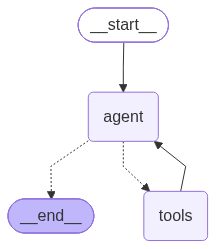

In [75]:
graph

In [77]:
result = graph.invoke(
    input={ "messages":[HumanMessage(content="How will be wather today?")]}
)
print(result)

{'messages': [HumanMessage(content='How will be wather today?', additional_kwargs={}, response_metadata={}, id='97925f8e-b5e7-4b9e-b2ed-78b92b6f29c7'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 97, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_fb616cb435', 'id': 'chatcmpl-ELuxKTLDaMMiTAcQBfZD650YUHMEA', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0824d-cddf-7962-a4f9-cf53115d294d-0', tool_calls=[{'name': 'off_topic', 'args': {}, 'id': 'call_LXxBUBlB7QPaQK8y5q95ENd3', 'type': 'tool_call'}], 

In [79]:
result = graph.invoke(
    input={ "messages":[HumanMessage(content="Who is the owner & what are the timing of peak performace gym")]}
)
print(result)

{'messages': [HumanMessage(content='Who is the owner & what are the timing of peak performace gym', additional_kwargs={}, response_metadata={}, id='73db7825-92d2-43e7-ac36-215d9e79eb4f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 104, 'total_tokens': 169, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_fb616cb435', 'id': 'chatcmpl-ELv0WR60ATFcLuHzE8RuHmu4xhqKp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a08250-d3fc-7001-8801-42b19e38478a-0', tool_calls=[{'name': 'retriever_tool', 'args': {'query': 'Who is the ow

In [81]:
result

{'messages': [HumanMessage(content='Who is the owner & what are the timing of peak performace gym', additional_kwargs={}, response_metadata={}, id='73db7825-92d2-43e7-ac36-215d9e79eb4f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 104, 'total_tokens': 169, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_fb616cb435', 'id': 'chatcmpl-ELv0WR60ATFcLuHzE8RuHmu4xhqKp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a08250-d3fc-7001-8801-42b19e38478a-0', tool_calls=[{'name': 'retriever_tool', 'args': {'query': 'Who is the 

In [82]:
print(result["messages"][-1].content)

The owner of Peak Performance Gym is Marcus Chen, a former Olympic athlete who founded the gym in 2015.

The operating hours of Peak Performance Gym are:
- Monday through Friday: 5:00 AM to 11:00 PM
- Weekends: (The specific weekend hours were not fully provided, but the gym is open on weekends as well.)

If you need the exact weekend hours, please let me know!
